<p align="left">
  <img src="../escudo_uach.png" width="100">
</p>

# Estudio y Experimentación sobre  Amortiguamiento Viscoso

### Integrantes:

* Carlos Durán
* Sebastián Muñoz

# 0. Importación de librerías

In [144]:
# 0. PREPARACIÓN DEL ENTORNO
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, find_peaks
try:
    import ipywidgets as widgets
    from ipywidgets import interact
    has_ipywidgets = True
except ModuleNotFoundError:
    has_ipywidgets = False

# Configuración base de gráficos
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)
print("Ambiente listo")

Ambiente listo


# 1. Sistema masa-resorte


La ecuación teórica de un sistema masa-resorte con una fuerza externa aplicada es: 
$$ m\ddot{x} + kx = f(t) $$
Si la excitación coincide con la frecuencia natural $f_n = \frac{1}{2\pi}\sqrt{k/m}$, el sistema entra en resonancia y la amplitud de vibración crece teóricamente hasta el infinito.

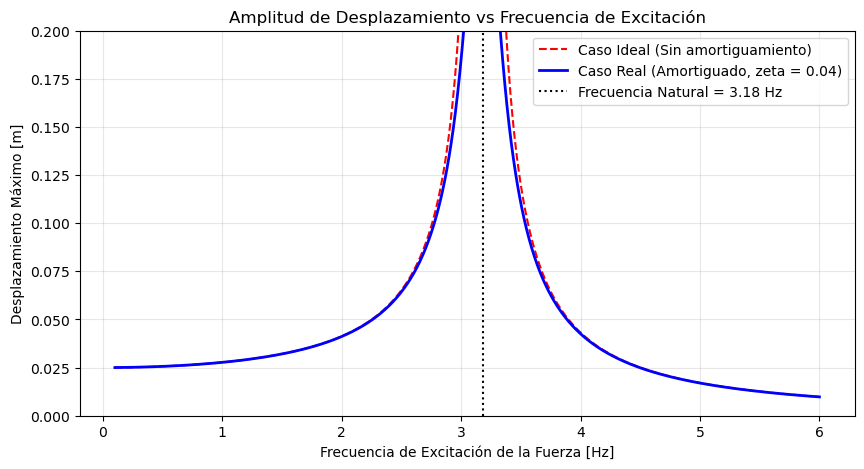

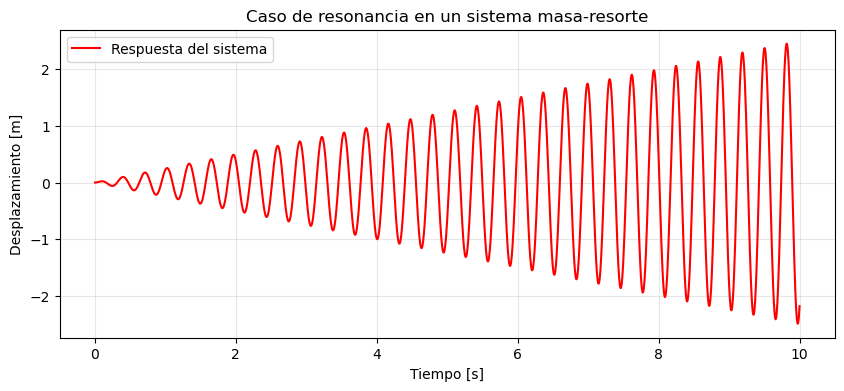

In [145]:
# 0.5 AMPLITUD DE DESPLAZAMIENTO VS FRECUENCIA DE EXCITACIÓN

# Parámetros del sistema
mass_eq = 10.0          # kg
stiffness_eq = 4000.0   # N/m
damping_ratio = 0.04    # zeta (Caso subamortiguado)
F0 = 100.0              # Magnitud constante de la fuerza externa (Newtons)

omega_n_eq = np.sqrt(stiffness_eq / mass_eq)
fn_eq_hz = omega_n_eq / (2 * np.pi)
c_eq = 2 * damping_ratio * mass_eq * omega_n_eq

# Rango de frecuencias de excitación (de 0.1 a 6 Hz para enfocarnos en la resonancia)
f_exc = np.linspace(0.1, 6, 1000)
omega_exc = 2 * np.pi * f_exc

# 1. Caso Ideal (Sin amortiguamiento, c = 0)
# La amplitud teórica es F0 / |k - m*omega^2|
# Usamos un pequeño valor epsilon en el denominador para evitar error de división por cero exacta en Python
X_undamped = F0 / (np.abs(stiffness_eq - mass_eq * omega_exc**2) + 1e-10)

# 2. Caso Real (Con amortiguamiento viscoso)
# La amplitud es F0 / sqrt((k - m*omega^2)^2 + (c*omega)^2)
X_damped = F0 / np.sqrt((stiffness_eq - mass_eq * omega_exc**2)**2 + (c_eq * omega_exc)**2)

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(f_exc, X_undamped, color='red', linestyle='--', label='Caso Ideal (Sin amortiguamiento)')
plt.plot(f_exc, X_damped, color='blue', linewidth=2, label=f'Caso Real (Amortiguado, zeta = {damping_ratio})')

plt.axvline(fn_eq_hz, color='black', linestyle=':', label=f'Frecuencia Natural = {fn_eq_hz:.2f} Hz')

plt.title('Amplitud de Desplazamiento vs Frecuencia de Excitación')
plt.xlabel('Frecuencia de Excitación de la Fuerza [Hz]')
plt.ylabel('Desplazamiento Máximo [m]')

# Limitamos el eje Y para poder ver la curva amortiguada sin que la curva ideal aplaste el gráfico
plt.ylim(0, 0.2) 
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 0.6 SIMULACIÓN DEL CASO IDEAL: RESONANCIA SIN AMORTIGUAMIENTO

# Parámetros del sistema ideal (sin amortiguador)
m_ideal = 10.0       # kg
k_ideal = 4000.0     # N/m
F0 = 100.0           # Amplitud de la fuerza externa (Newtons)

omega_n_ideal = np.sqrt(k_ideal / m_ideal)
fn_ideal = omega_n_ideal / (2 * np.pi)

# Vector de tiempo (10 segundos)
t_res = np.linspace(0, 10, 2000)

envelope = (F0 / (2 * m_ideal * omega_n_ideal)) * t_res
x_resonance = envelope * np.sin(omega_n_ideal * t_res)

# Gráfico
plt.figure(figsize=(10, 4))
plt.plot(t_res, x_resonance, label="Respuesta del sistema", color='red')
# plt.plot(t_res, envelope, '--', color='black', alpha=0.8, label="Envolvente de crecimiento lineal")
# plt.plot(t_res, -envelope, '--', color='black', alpha=0.8)

plt.title(f"Caso de resonancia en un sistema masa-resorte")
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



La solución para este problema se logra mediante el **amortiguamiento**. Al agregarlo, la ecuación real es:
$$ m\ddot{x} + c\dot{x} + kx = f(t) $$

---
**🗣️ GUION PARA EXPONER (Lo que debes decirle al profesor aquí):**
*   *"Para entender por qué las estructuras no colapsan todos los días, primero imaginemos un sistema ideal (masa-resorte). Si lo excitamos en su frecuencia natural, la resonancia destruiría la estructura."*
*   *"Aquí entra la solución: el amortiguamiento viscoso ($c\dot{x}$), que disipa energía de forma proporcional a la velocidad."*
*   *(MUY IMPORTANTE)* *"Es vital destacar que la ecuación de decaimiento que solemos usar en los libros ($x(t) = x_0 e^{-\zeta\omega_n t} \cos(\omega_d t)$) corresponde **únicamente** al caso **subamortiguado** ($0 < \zeta < 1$). Si el sistema fuera crítico o sobreamortiguado ($\zeta \ge 1$), no habría senos ni cosenos porque la estructura no oscilaría en absoluto, sino que tendría un decaimiento aperiódico puro de regreso al reposo."*

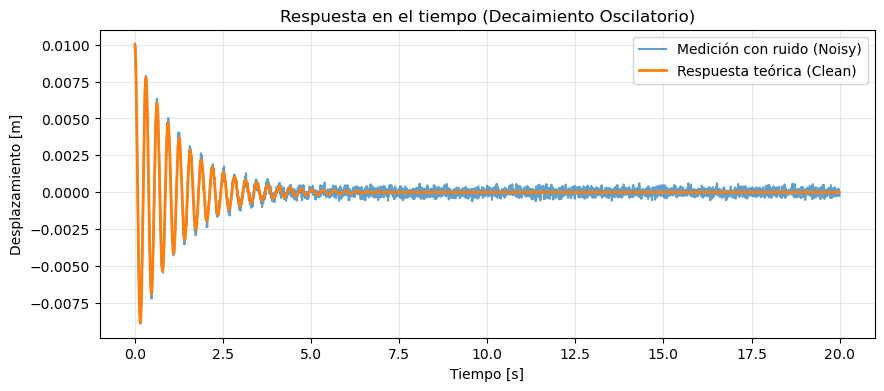

In [146]:
# 1. PARÁMETROS Y SIMULACIÓN EN EL TIEMPO

# Parámetros físicos del sistema
mass = 10.0          # kg
stiffness = 4000.0   # N/m
damping_ratio = 0.04 # Razón de amortiguamiento (subamortiguado)

omega_n = np.sqrt(stiffness / mass)
omega_d = omega_n * np.sqrt(1 - damping_ratio**2)
fn_hz = omega_n / (2 * np.pi)

# Simulación temporal
sampling_frequency = 200.0
duration = 20.0
initial_displacement = 0.01 # m
t = np.arange(0, duration, 1 / sampling_frequency)

# Respuesta analítica (Válida solo para Caso Subamortiguado)
x_clean = initial_displacement * np.exp(-damping_ratio * omega_n * t) * np.cos(omega_d * t)

# Añadir ruido para simular medición experimental real
rng = np.random.default_rng(42)
noise_std = 0.02
noise = rng.normal(
    loc=0.0,
    scale=noise_std * np.max(np.abs(x_clean)),
    size=len(t)
)
x_noisy = x_clean + noise

# Gráfico de la respuesta en el tiempo
plt.figure(figsize=(10, 4))
plt.plot(t, x_noisy, label="Medición con ruido (Noisy)", alpha=0.7)
plt.plot(t, x_clean, linewidth=2, label="Respuesta teórica (Clean)")
plt.title("Respuesta en el tiempo (Decaimiento Oscilatorio)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

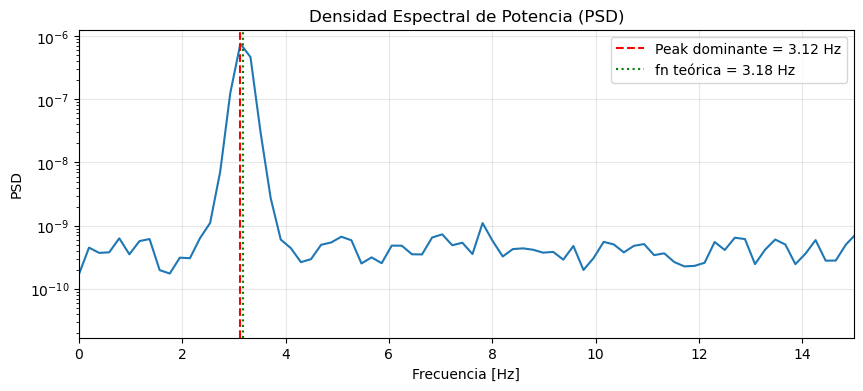

In [147]:
# 2. CÁLCULO DE LA DENSIDAD ESPECTRAL DE POTENCIA (PSD)
frequencies, psd = welch(
    x_noisy,
    fs=sampling_frequency,
    nperseg=1024,
    noverlap=512
)
dominant_frequency = frequencies[np.argmax(psd)]

plt.figure(figsize=(10, 4))
plt.semilogy(frequencies, psd, color='#1f77b4')
plt.axvline(dominant_frequency, linestyle="--", color='red', label=f"Peak dominante = {dominant_frequency:.2f} Hz")
plt.axvline(fn_hz, linestyle=":", color='green', label=f"fn teórica = {fn_hz:.2f} Hz")
plt.title("Densidad Espectral de Potencia (PSD)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.xlim(0, 15)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2. Midiendo la solución empíricamente

En la práctica, evaluamos el amortiguamiento a partir de la envolvente exponencial usando el **Decremento Logarítmico ($\delta$)**:
$$ \delta = \frac{1}{n}\ln\left(\frac{x_i}{x_{i+n}}\right) \implies \zeta = \frac{\delta}{\sqrt{4\pi^2 + \delta^2}} $$

---
**🗣️ GUION PARA EXPONER:**
*   *"Sabemos que el amortiguamiento salva la estructura de la resonancia, pero en la vida real no conocemos $\zeta$. Tenemos que medirlo empíricamente tras un impacto."*
*   *"Como la amplitud decae por una envolvente exponencial, el Decremento Logarítmico aplica un logaritmo natural al cociente de dos amplitudes para cancelar el efecto exponencial y aislar $\zeta$."*
*   *"Si notan en nuestro código, saltamos $n$ ciclos para medir. Esto se hace porque el ruido en las señales experimentales provoca que la caída entre dos picos consecutivos sea casi microscópica; separar los picos minimiza enormemente la incerteza introducida por el ruido de medición."*

Razón de amortiguamiento real (teórica) : 0.0400
Razón de amortiguamiento estimada     : 0.0348


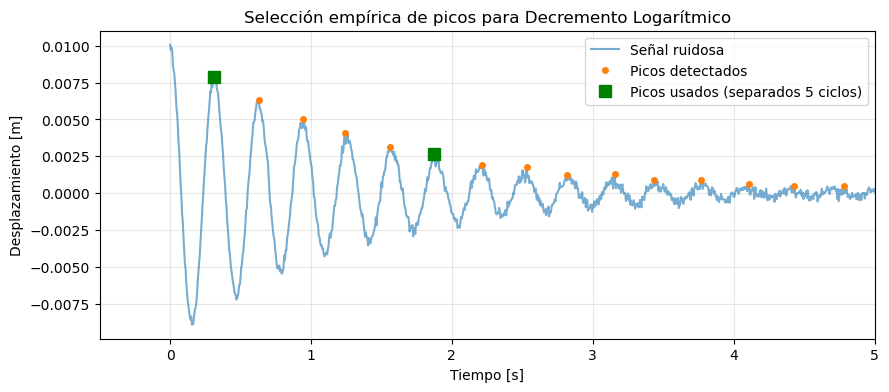

In [148]:
# 3. DETECCIÓN DE PICOS Y CÁLCULO DEL DECREMENTO LOGARÍTMICO
period_samples = int((1 / (omega_d / (2 * np.pi))) * sampling_frequency)
peaks, _ = find_peaks(x_noisy, distance=int(0.7 * period_samples), prominence=0.0002)
peak_times = t[peaks]
peak_values = x_noisy[peaks]

# Filtrar solo picos positivos
pos_mask = peak_values > 0
peak_times = peak_times[pos_mask]
peak_values = peak_values[pos_mask]
peaks = peaks[pos_mask]

# Elegir dos picos separados por n ciclos
i = 0
n_cycles = 5
x_i = peak_values[i]
x_i_n = peak_values[i + n_cycles]
t_i = peak_times[i]
t_i_n = peak_times[i + n_cycles]

# Estimación de parámetros
delta_est = (1 / n_cycles) * np.log(x_i / x_i_n)
zeta_est = delta_est / np.sqrt(4 * np.pi**2 + delta_est**2)

print(f"Razón de amortiguamiento real (teórica) : {damping_ratio:.4f}")
print(f"Razón de amortiguamiento estimada     : {zeta_est:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(t, x_noisy, label="Señal ruidosa", alpha=0.6)
plt.plot(peak_times, peak_values, "o", markersize=4, label="Picos detectados")
plt.plot([t_i, t_i_n], [x_i, x_i_n], "s", markersize=9, color='green', label=f"Picos usados (separados {n_cycles} ciclos)")
plt.xlim(-0.5, 5) 
plt.title("Selección empírica de picos para Decremento Logarítmico")
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [149]:
# 4. HERRAMIENTA INTERACTIVA DE AJUSTE (Slider)
def plot_interactive_response(zeta_val):
    # Condición para evitar raíces imaginarias si se supera zeta = 1 
    omega_d_loc = omega_n * np.sqrt(max(0.0, 1 - zeta_val**2))
    
    # Respuesta
    x_int = initial_displacement * np.exp(-zeta_val * omega_n * t) * np.cos(omega_d_loc * t)
    
    plt.figure(figsize=(10, 4))
    plt.plot(t, x_int, label='Respuesta amortiguada', color='darkorange', linewidth=2)
    plt.title(f"Ajuste en vivo: Razón de Amortiguamiento (zeta) = {zeta_val:.2f}")
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Desplazamiento [m]')
    plt.xlim(0, 10)
    plt.grid(True, alpha=0.5)
    plt.legend()
    plt.show()

if has_ipywidgets:
    interact(plot_interactive_response, zeta_val=widgets.FloatSlider(value=0.04, min=0.01, max=1.2, step=0.02, description='Zeta:'))
else:
    print("Módulo ipywidgets no instalado. Visualización interactiva deshabilitada.")

interactive(children=(FloatSlider(value=0.04, description='Zeta:', max=1.2, min=0.01, step=0.02), Output()), _…

# 3. El panorama completo frente a cualquier excitación

La **Admitancia Dinámica** ($X/F$) nos muestra cómo responde la estructura frente a un espectro de frecuencias continuas:
$$ H(\omega) = \frac{1}{k - m\omega^2 + jc\omega} $$

---
**🗣️ GUION PARA EXPONER:**
*   *"Ya vimos cómo decae un impacto libre en el tiempo. Ahora, ¿qué pasa si la fuerza externa empuja continuamente a la estructura en distintas frecuencias? Para eso graficamos la Admitancia."*
*   *(Muestra el gráfico de las 3 zonas)* *"El denominador de nuestra ecuación dicta qué parámetro físico 'controla' o salva a la estructura en cada momento:"*
    1.  *"A baja frecuencia, la velocidad y la aceleración (inercia) son casi nulas. La estructura está **Controlada por la Rigidez ($k$)**."*
    2.  *"En resonancia, la rigidez y la inercia chocan y se anulan mutuamente ($k - m\omega^2 \approx 0$). Quien salva a la estructura de un colapso infinito es exclusivamente el **Control por Amortiguamiento ($jc\omega$)**."*
    3.  *"A alta frecuencia, la aceleración crece al cuadrado. La inercia domina de forma absoluta. Tenemos **Control por Masa ($m\omega^2$)**."*
*   *(Muestra el último gráfico)* *"Para concluir, aunque todo nuestro desarrollo teórico analizó Desplazamiento/Fuerza (Admitancia), en la práctica del análisis modal experimental medimos la **Acelerancia** (Aceleración/Fuerza) porque los sensores que instalamos en terreno son acelerómetros y martillos modales."*

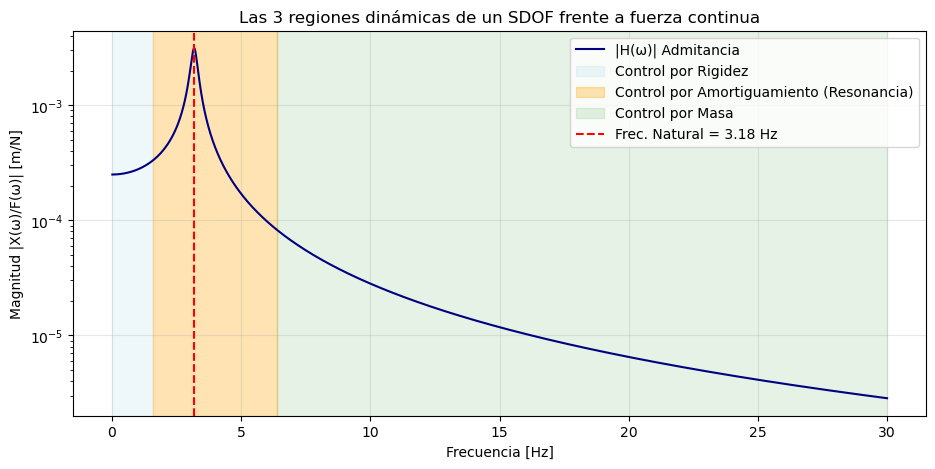

In [150]:
# 5. ZONAS DE CONTROL DINÁMICO EN LA FRF (Admitancia)
frequencies_hz = np.linspace(0.01, 30, 3000)
omega = 2 * np.pi * frequencies_hz
c = 2 * damping_ratio * mass * omega_n

H = 1 / (stiffness - mass * omega**2 + 1j * c * omega)
H_magnitude = np.abs(H)

low_freq_limit = 0.5 * fn_hz
high_freq_limit = 2.0 * fn_hz

plt.figure(figsize=(11, 5))
plt.semilogy(frequencies_hz, H_magnitude, color='navy', label="|H(ω)| Admitancia")

# Zonas sombreadas
plt.axvspan(0, low_freq_limit, alpha=0.2, color='lightblue', label="Control por Rigidez")
plt.axvspan(low_freq_limit, high_freq_limit, alpha=0.3, color='orange', label="Control por Amortiguamiento (Resonancia)")
plt.axvspan(high_freq_limit, 30, alpha=0.1, color='green', label="Control por Masa")

plt.axvline(fn_hz, linestyle="--", color='red', label=f"Frec. Natural = {fn_hz:.2f} Hz")
plt.title("Las 3 regiones dinámicas de un SDOF frente a fuerza continua")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud |X(ω)/F(ω)| [m/N]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

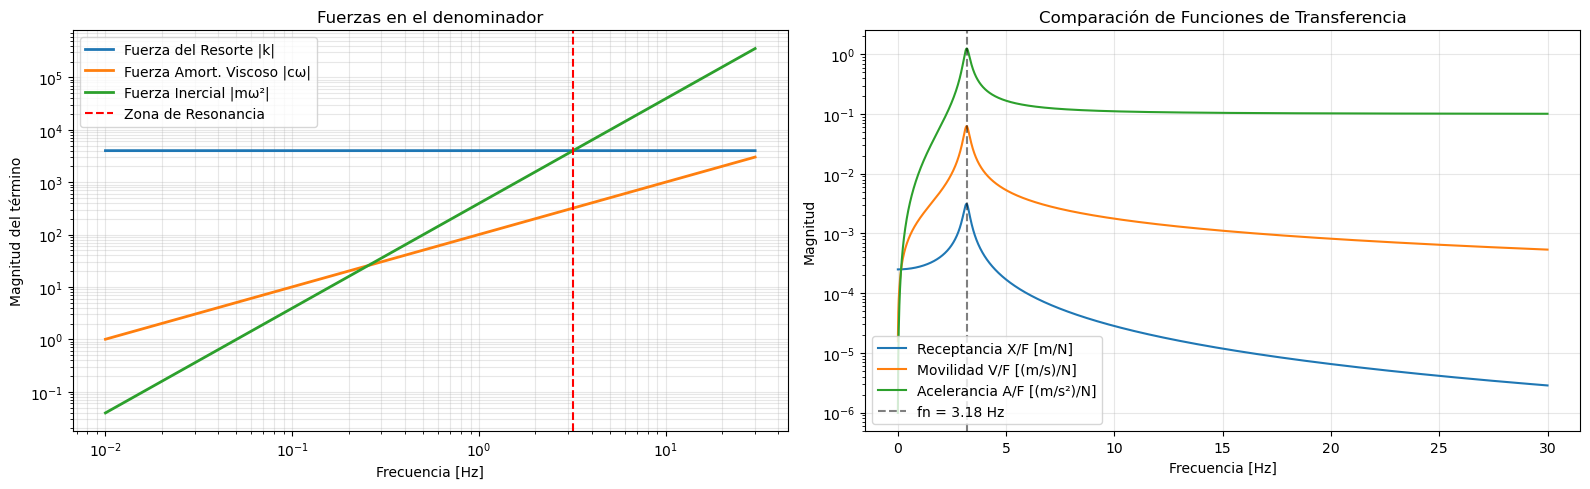

In [151]:
# 6. DEMOSTRACIÓN MATEMÁTICA DEL DENOMINADOR Y COMPARACIÓN DE FRFs
elastic_term = np.ones_like(omega) * stiffness
damping_term = c * omega
inertial_term = mass * omega**2

# Subplot 1: Términos del denominador
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.loglog(frequencies_hz, elastic_term, linewidth=2, label="Fuerza del Resorte |k|")
ax1.loglog(frequencies_hz, damping_term, linewidth=2, label="Fuerza Amort. Viscoso |cω|")
ax1.loglog(frequencies_hz, inertial_term, linewidth=2, label="Fuerza Inercial |mω²|")
ax1.axvline(fn_hz, linestyle="--", color='red', label="Zona de Resonancia")
ax1.set_title("Fuerzas en el denominador")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Magnitud del término")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

# Subplot 2: Otras FRFs (Admitancia vs Movilidad vs Acelerancia)
H_velocity = 1j * omega * H
H_acceleration = -(omega**2) * H

ax2.semilogy(frequencies_hz, np.abs(H), label="Receptancia X/F [m/N]")
ax2.semilogy(frequencies_hz, np.abs(H_velocity), label="Movilidad V/F [(m/s)/N]")
ax2.semilogy(frequencies_hz, np.abs(H_acceleration), label="Acelerancia A/F [(m/s²)/N]")
ax2.axvline(fn_hz, linestyle="--", color='black', alpha=0.5, label=f"fn = {fn_hz:.2f} Hz")
ax2.set_title("Comparación de Funciones de Transferencia")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Magnitud")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()